In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import json 
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter 
from scipy.signal import find_peaks
from Oscilloscope.Oscilloscope import Oscilloscope

**burada işimizi kolaylaştırmak Oscilloscope adında bir class oluşturdum**

In [2]:
osiloskop_info = Oscilloscope(['detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/' +str(x)+'.bin' for x in range(0,902)])
osiloskop_info.__dict__

{'file_paths': ['detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/0.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/1.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/2.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/3.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/4.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/5.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/6.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/7.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/8.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/9.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/10.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/11.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/12.bin',
  'detektor data 2/P10/Kare/Kare 10x10/6x6/p10 7000V Cs 2.kez/13.bin',
  

In [3]:
#osiloskop_info.saveAsJson('berker/data.json')

In [4]:
readData = pd.DataFrame(osiloskop_info.channel[1].data)

In [5]:
readData[readData[0]>0.25]

,0
44,0.28
45,0.28
46,0.28
47,0.28
48,0.32
...,...
685488,0.28
685514,0.40
685515,0.28
685516,0.28


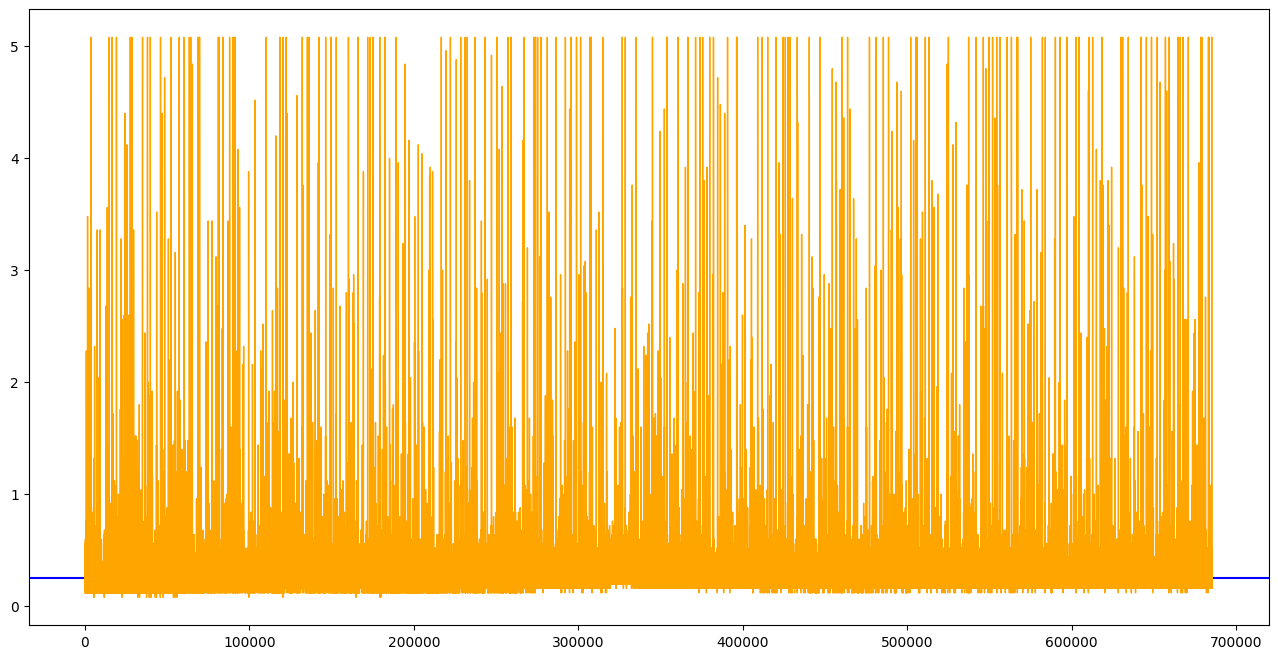

In [6]:
plt.figure(figsize=(16, 8))
plt.axhline(0.25, color = 'blue', linestyle = '-')
plt.plot(readData, color="orange", linewidth=1)

In [7]:
smootedData = readData[[0]].apply(savgol_filter,  window_length=4, polyorder=3)
smootedData2 = smootedData[[0]].apply(savgol_filter,  window_length=5, polyorder=3)

array([[<Axes: title={'center': '0'}>]], dtype=object)

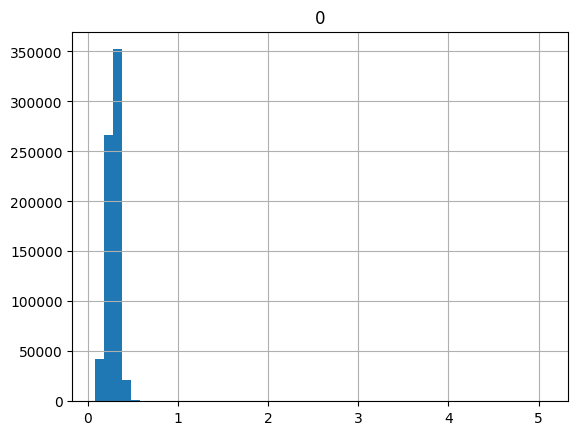

In [8]:
readData.hist(bins=50)

In [9]:
np.histogram(readData[[0]],bins = 50)

(array([ 42122, 266323, 352156,  21302,   1097,    645,    426,    140,
           177,    103,    117,     96,     58,     57,     34,     70,
            25,     39,     18,     23,     24,     28,     19,     30,
            15,     11,     16,     25,     11,      8,     11,     15,
            14,     19,      8,      4,     10,     15,      8,      4,
             9,      4,      4,      7,      5,      7,      3,      7,
             5,    146]),
 array([0.08, 0.18, 0.28, 0.38, 0.48, 0.58, 0.68, 0.78, 0.88, 0.98, 1.08,
        1.18, 1.28, 1.38, 1.48, 1.58, 1.68, 1.78, 1.88, 1.98, 2.08, 2.18,
        2.28, 2.38, 2.48, 2.58, 2.68, 2.78, 2.88, 2.98, 3.08, 3.18, 3.28,
        3.38, 3.48, 3.58, 3.68, 3.78, 3.88, 3.98, 4.08, 4.18, 4.28, 4.38,
        4.48, 4.58, 4.68, 4.78, 4.88, 4.98, 5.08]))

In [10]:
sorted = readData.sort_values(0)
filtered = sorted[int(len(sorted)*0.2):int(len(sorted)*0.80)]
filtered

,0
647240,0.20
647239,0.20
647247,0.20
271334,0.20
23896,0.20
...,...
212773,0.32
482006,0.32
212772,0.32
480276,0.32


In [11]:
mode = readData.mode()
mode

,0
0,0.32


In [12]:
std = np.std(filtered[0])
std

0.03951696064615059

In [13]:
avg = np.average(filtered[0])
avg

0.27247208931419475

In [14]:
trshld = avg + std*(1+2**0.5)
peaks, _ = find_peaks(smootedData[0],prominence=std*3 , wlen=21)
peaks

/var/folders/f2/cxyt29q57rx_mqk_s23j484c0000gn/T/ipykernel_44868/3577060018.py:2: PeakPropertyWarning: some peaks have a prominence of 0
  peaks, _ = find_peaks(smootedData[0],prominence=std*3 , wlen=21)


array([    76,    146,    257, ..., 685215, 685286, 685487])

In [15]:
len(peaks)

3486

In [16]:
filtredPeaks = smootedData[0][peaks][smootedData[0] > -10000000]
filtredPeaks = filtredPeaks.keys()

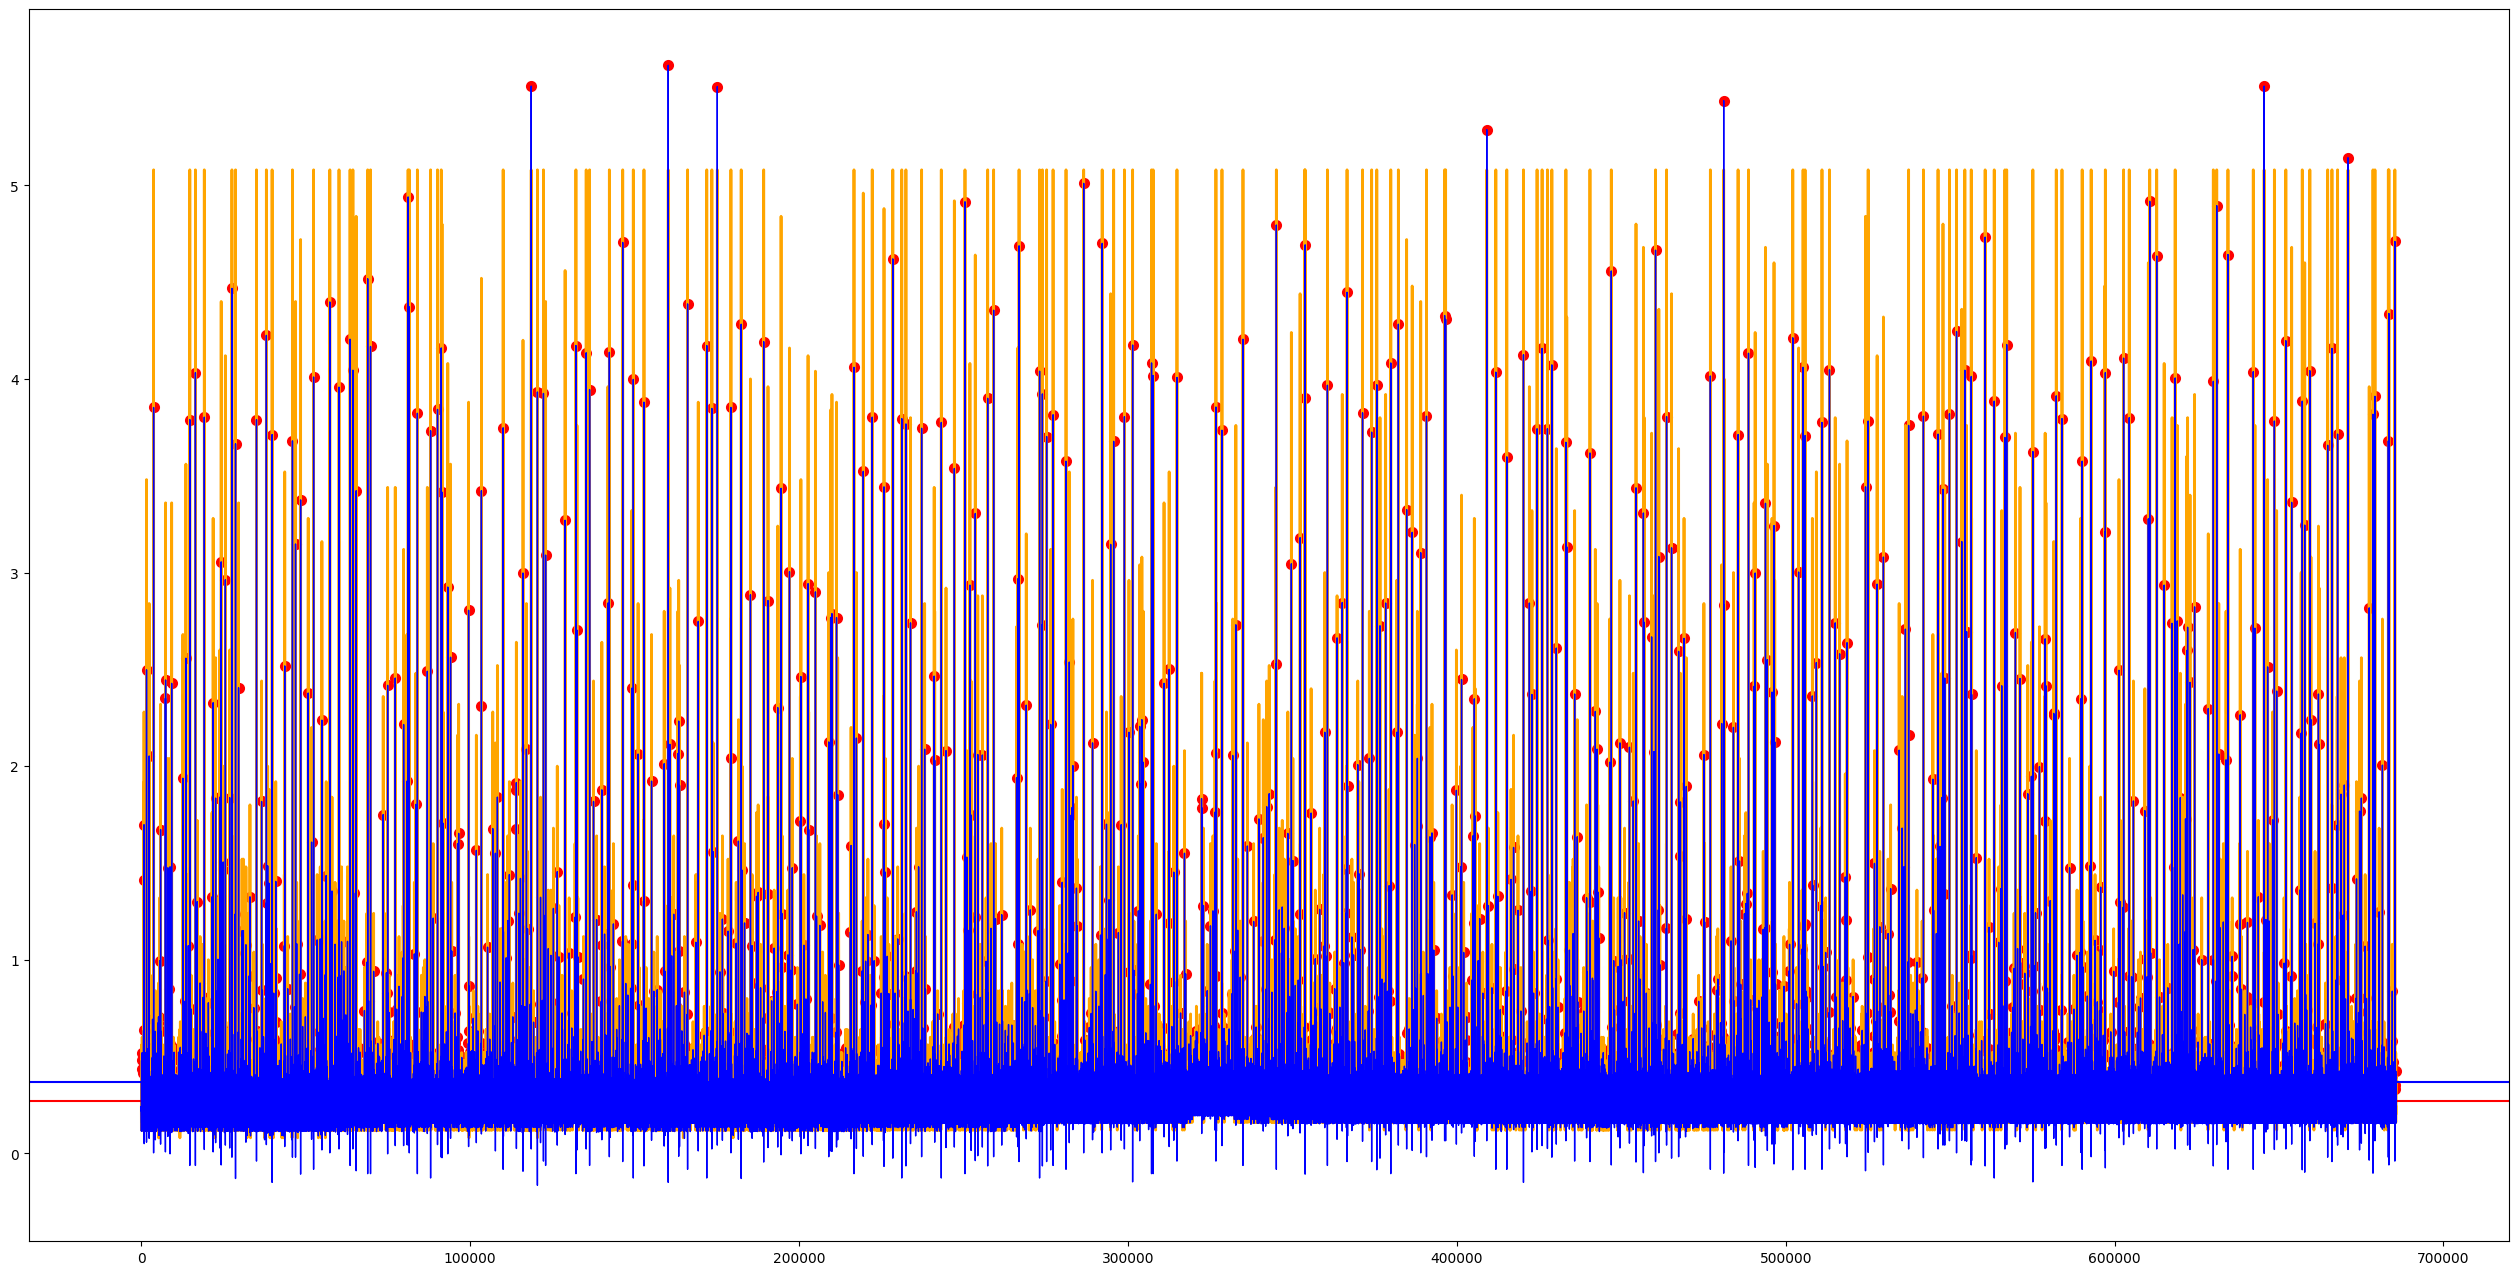

In [17]:

plt.figure(figsize=(32, 16))
plt.plot(range(0,len(readData)),readData, color="orange", linewidth=2)

plt.axhline(avg, color = 'r', linestyle = '-')
plt.axhline(trshld, color = 'blue', linestyle = '-')

plt.plot(range(0,len(smootedData)),smootedData, color="blue", linewidth=1)
##plt.plot(range(0,len(smootedData2)),smootedData2, color="purple", linewidth=1)
plt.scatter(filtredPeaks,smootedData[0][filtredPeaks], color="red", linewidth=2)

plt.show()

In [18]:
readData[readData[0]> trshld] 

,0
76,0.56
146,0.48
257,0.60
258,0.40
490,0.48
...,...
685440,0.40
685449,0.40
685450,0.40
685487,0.52
